In [83]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

In [84]:
df = pd.read_csv('StudentsPerformance.csv')
df


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [85]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
       df[col] = le.fit_transform(df[col])
df['average score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,0,1,1,1,1,72,72,74,72.666667
1,0,2,4,1,0,69,90,88,82.333333
2,0,1,3,1,1,90,95,93,92.666667
3,1,0,0,0,1,47,57,44,49.333333
4,1,2,4,1,1,76,78,75,76.333333


In [86]:
df['pass']=(df['average score']>50).astype(int)
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score,pass
0,0,1,1,1,1,72,72,74,72.666667,1
1,0,2,4,1,0,69,90,88,82.333333,1
2,0,1,3,1,1,90,95,93,92.666667,1
3,1,0,0,0,1,47,57,44,49.333333,0
4,1,2,4,1,1,76,78,75,76.333333,1
...,...,...,...,...,...,...,...,...,...,...
995,0,4,3,1,0,88,99,95,94.000000,1
996,1,2,2,0,1,62,55,55,57.333333,1
997,0,2,2,0,0,59,71,65,65.000000,1
998,0,3,4,1,0,68,78,77,74.333333,1


In [87]:
passed=df['pass'].sum()
print(f"Number of students passed : {passed}")

Number of students passed : 891


In [88]:
not_passed=(df['pass']==0).sum()
print(f"Number of students who did not pass : {not_passed}")

Number of students who did not pass : 109


In [89]:
X = df.drop(['pass'], axis=1)
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model= DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00       171

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



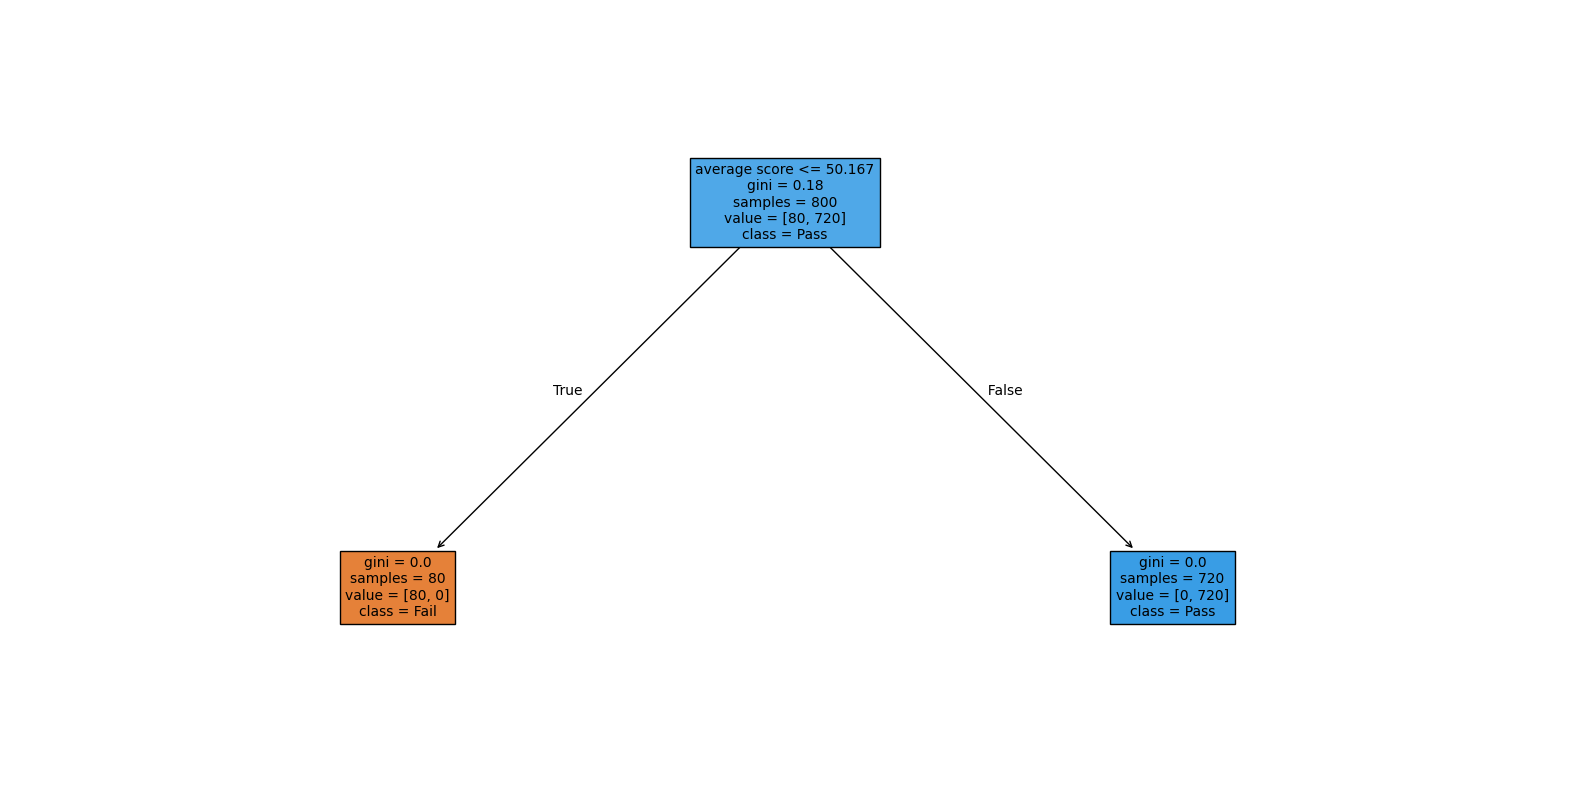

In [90]:
plt.figure(figsize=(20,10))

plot_tree(model,
          feature_names=X.columns,
          class_names=["Fail", "Pass"],
          filled=True,
          fontsize=10)

plt.show()
